## Mount Google Drive

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Paths

In [17]:
import os

base_path = "/content/drive/MyDrive/Deep-Learning/Study03/MLP_Backprop"
notebook_path = os.path.join(base_path, "notebooks")
visuals_path = os.path.join(base_path, "Visuals")

os.makedirs(notebook_path, exist_ok=True)
os.makedirs(visuals_path, exist_ok=True)

print("Folders ready")

Folders ready


## Import Libraries

In [18]:
import numpy as np
import matplotlib.pyplot as plt

## XOR Dataset

In [19]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([[0],[1],[1],[0]])

print("X:\n", X)
print("y:\n", y)

X:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
y:
 [[0]
 [1]
 [1]
 [0]]


## XOR / Visualization

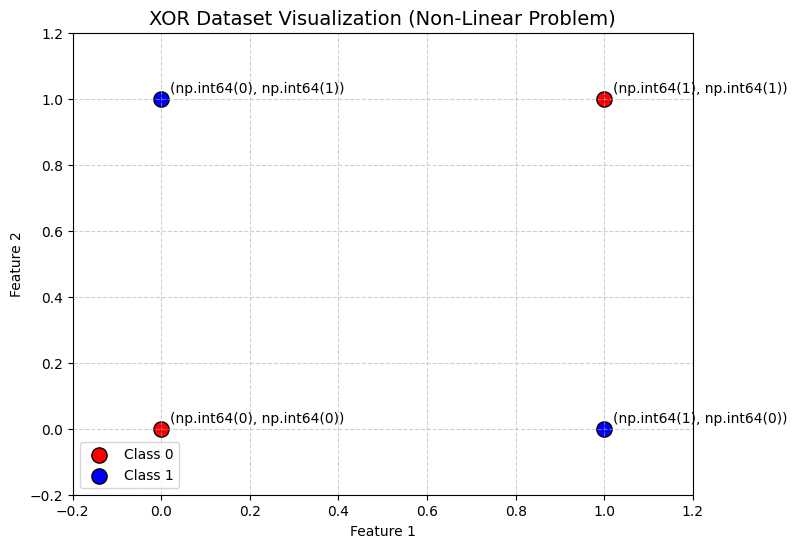

In [20]:
import os

plt.figure(figsize=(8,6))

class0 = X[y.flatten() == 0]
class1 = X[y.flatten() == 1]


plt.scatter(class0[:,0], class0[:,1],
            color='red', edgecolors='black', s=120, label='Class 0')

plt.scatter(class1[:,0], class1[:,1],
            color='blue', edgecolors='black', s=120, label='Class 1')


for i, txt in enumerate(y.flatten()):
    plt.annotate(f"{tuple(X[i])}", (X[i][0]+0.02, X[i][1]+0.02), fontsize=10)


plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)

plt.title("XOR Dataset Visualization (Non-Linear Problem)", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

save_path = os.path.join(visuals_path, "xor_dataset_advanced.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

## MLP Architecture
Initialize Parameters

In [21]:
np.random.seed(42)

input_size = 2
hidden_size = 4
output_size = 1

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

learning_rate = 0.1

## Forward Propagation
Activation Functions

In [22]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

In [23]:
def forward(X):
    global Z1, A1, Z2, A2

    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    return A2

## Backward Function

In [24]:
def backward(X, y):
    global W1, b1, W2, b2

    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

## Model Training

In [25]:
losses = []

for epoch in range(5000):
    output = forward(X)
    loss = np.mean((y - output)**2)
    losses.append(loss)

    backward(X, y)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.28318958906443975
Epoch 1000, Loss: 0.24522394650749285
Epoch 2000, Loss: 0.21133423687046915
Epoch 3000, Loss: 0.1460339660196695
Epoch 4000, Loss: 0.04037693911653088


## Plot Loss Curve

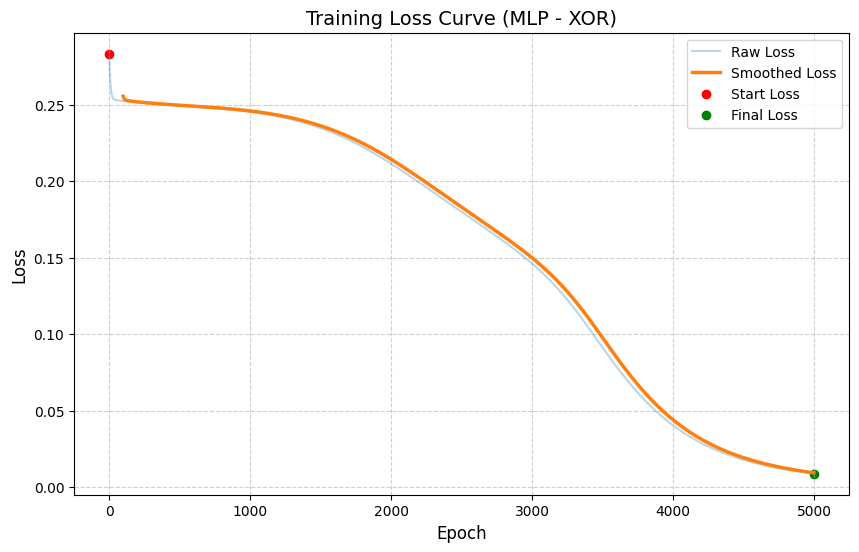

In [26]:
import os


losses_np = np.array(losses)


window = 100
smoothed_losses = np.convolve(losses_np, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,6))


plt.plot(losses_np, alpha=0.3, label="Raw Loss")

plt.plot(range(window-1, len(losses_np)), smoothed_losses, linewidth=2.5, label="Smoothed Loss")

plt.scatter(0, losses_np[0], color='red', label="Start Loss")
plt.scatter(len(losses_np)-1, losses_np[-1], color='green', label="Final Loss")


plt.title("Training Loss Curve (MLP - XOR)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)


plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

save_path = os.path.join(visuals_path, "xor_loss_advanced.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

## Final Predictions

In [28]:
predictions = forward(X)

print("Predictions:")
print(np.round(predictions))

Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


## Decision Boundary Visualization

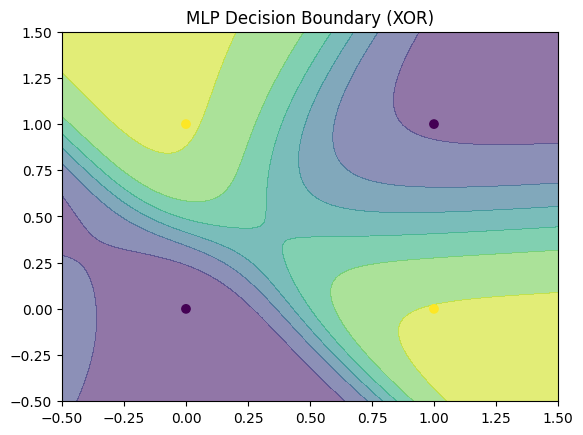

In [29]:
def plot_decision_boundary():
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = forward(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.flatten())

    plt.title("MLP Decision Boundary (XOR)")

    save_path = os.path.join(visuals_path, "decision_boundary.png")
    plt.savefig(save_path)

    plt.show()

plot_decision_boundary()

## CONCLUSIONS:
This lab demonstrated how a Multilayer Perceptron (MLP) overcomes the limitations of a single-layer perceptron by learning non-linear patterns such as the XOR problem. I implemented forward propagation and backpropagation using gradient descent, which helped me understand how neural networks update weights to minimize error. The results showed successful convergence and accurate predictions, confirming that the model achieved the intended objective. Overall, this lab strengthened my understanding of hidden layers, activation functions, and the core working mechanism of deep learning models.